In [17]:
from pathlib import Path
import re
import pandas as pd
import seaborn as sns

sns.set_context(sns.plotting_context(), font_scale=1.4)

In [18]:
WORKLOADS = ["faiss_10M", "lulesh2.0_s400", "DuckDB-TPCH-sf100", "DuckDB-TPCDS-sf100", "mg.D.x", "XSBench", "pr-kron.sg", "pr-twitter.sg", "bc-kron.sg", "bc-twitter.sg"]

In [19]:
def parse_time_value(raw: str) -> float:
    """Convert strings like '7m56.676s' into seconds."""

    raw = raw.strip()
    match = re.fullmatch(r"(?:(\d+)m)?([0-9.]+)s", raw)
    if not match:
        raise ValueError(f"Unrecognized time format: {raw}")
    minutes = int(match.group(1) or 0)
    seconds = float(match.group(2))
    return minutes * 60 + seconds

def parse_time_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "\t" not in line:
                continue
            key, value = line.split("\t", 1)
            metrics[key] = parse_time_value(value)
    return metrics

def extract_mib(path: Path) -> int | None:
    match = re.search(r"(\d+)MiB", path.name)
    return (int(match.group(1)) // 100) * 100 if match else None


def extract_run(path: Path) -> int | None:
    match = re.search(r"run(\d+)", path.name)
    return int(match.group(1)) if match else None

def parse_l2_value(raw: str) -> bool | int | float | str:
    if raw == "true":
        return True
    if raw == "false":
        return False
    if re.fullmatch(r"\d+", raw):
        return int(raw)
    if re.fullmatch(r"\d+\.\d+", raw):
        return float(raw)
    return raw

def parse_log_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "=" not in line:
                continue
            key, value = line.split("=", 1)
            metrics[key.strip()] = float(value.strip())
    return metrics

In [20]:
def generate_df(roots_gen: callable) -> pd.DataFrame:
    dfs = []

    for workload in WORKLOADS:
        records: list[dict] = []
        for label, (kernel, root) in roots_gen(workload).items():
            for path in sorted(root.glob("*.time")):
                if "train" in path.name:
                    continue
                metrics = parse_time_file(path)
                try:
                    log_metrics = parse_log_file(Path(f"{path.parent}/max_dram_hugepages_{path.stem}.log"))
                except FileNotFoundError:
                    log_metrics = {}

                m = re.search(
                    r"^(?P<mib>\d+)MiB_run(?P<run>\d+)_(?P<model>[^_]+)_discounted_reward_(?P<discounted_reward>\d+)_(?P<workload>.+)_l2-(?P<l2>[^_]+)_(?P<hist_length>\d+)_(?P<penalty>[0-9]+(?:\.[0-9]+)?)(?:\.time)?$",
                    path.name,
                )
                parsed = {}
                if m:
                    l2_value = parse_l2_value(m.group("l2"))
                    parsed = {
                        "MiB": int(m.group("mib")) // 100 * 100,
                        "run": int(m.group("run")),
                        "model": m.group("model"),
                        "filename_workload": m.group("workload"),
                        "discounted_reward": int(m.group("discounted_reward")),
                        "l2": l2_value,
                        "minmax": l2_value if isinstance(l2_value, bool) else None,
                        "hist_length": int(m.group("hist_length")),
                        "penalty": float(m.group("penalty")),
                    }

                records.append({
                    "policy": label,
                    "kernel": kernel,
                    "file": path.name,
                    "MiB": extract_mib(path),
                    "run": extract_run(path),
                    **metrics,
                    **log_metrics,
                    **parsed,
                })

        df = pd.DataFrame(records)
        df["workload"] = workload

        dfs.append(df)
    df = pd.concat(dfs, ignore_index=True)
    return df

In [21]:
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba
import matplotlib.pyplot as plt

FIXED_POLICY_COLORS = {
    "manta": "#377eb8",
    "arms": "#ff7f00",
    "tpp": "#984ea3",
    "nomad": "#e41a1c",
    "hybridtier": "#4daf4a",
}

FALLBACK_POLICY_COLORS = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#2ec3da",
    "#a6761d",
    "#f781bf",
]

PENALTY_GRADIENT_BASE = "#e7298a"
PENALTY_BASELINE_GAP_FACTOR = 0.45

def normalize_policy_name(name: object) -> str:
    return str(name).strip().lower()

def build_penalty_gradient_palette(
    plot_data: pd.DataFrame,
    hue_col: str,
    policy_order: list[str],
) -> dict[str, str | tuple[float, float, float]]:
    palette: dict[str, str | tuple[float, float, float]] = {}
    label_details = (
        plot_data[[hue_col, "policy", "penalty"]]
        .drop_duplicates(subset=[hue_col])
        .set_index(hue_col)
    )

    gradient_labels = []
    for label in policy_order:
        if label in label_details.index:
            base_policy = normalize_policy_name(label_details.at[label, "policy"])
        else:
            base_policy = normalize_policy_name(label)

        if base_policy in FIXED_POLICY_COLORS:
            palette[label] = FIXED_POLICY_COLORS[base_policy]
        else:
            gradient_labels.append(label)

    if gradient_labels:
        gradient_frame = (
            label_details.loc[gradient_labels].reset_index()
            .sort_values("penalty", na_position="last")
        )
        ordered_gradient_labels = gradient_frame[hue_col].tolist()
        gradient_colors = sns.light_palette(
            PENALTY_GRADIENT_BASE,
            n_colors=len(ordered_gradient_labels) + 2,
        )[1:-1]
        for label, color in zip(ordered_gradient_labels, gradient_colors):
            palette[label] = color

    return {label: palette[label] for label in policy_order}

def build_policy_palette(policy_order: list[str]) -> dict[str, str | tuple[float, float, float]]:
    palette: dict[str, str | tuple[float, float, float]] = {}
    remaining_colors = [
        color for color in FALLBACK_POLICY_COLORS if color not in FIXED_POLICY_COLORS.values()
    ]
    remaining_index = 0

    for label in policy_order:
        normalized = normalize_policy_name(label)
        if normalized in FIXED_POLICY_COLORS:
            palette[label] = FIXED_POLICY_COLORS[normalized]
        else:
            palette[label] = remaining_colors[remaining_index % len(remaining_colors)]
            remaining_index += 1

    return palette

def build_legend_label(
    plot_data: pd.DataFrame,
    hue_col: str,
    label: str,
    model_policy_key: str,
) -> str:
    if hue_col != "policy_penalty":
        return str(label)

    matching_rows = plot_data.loc[plot_data[hue_col] == label, "policy"]
    if matching_rows.empty:
        return str(label)

    policy_label = str(matching_rows.iloc[0])
    if normalize_policy_name(policy_label) == model_policy_key:
        return policy_label

    return str(label)

def apply_penalty_baseline_gap(
    ax,
    bar_containers,
    workload_df: pd.DataFrame,
    hue_col: str,
    local_hue_order: list[str],
    model_policy_key: str,
):
    if hue_col != "policy_penalty" or len(local_hue_order) < 2 or not bar_containers:
        return

    baseline_count = 0
    for label in local_hue_order:
        matching_rows = workload_df.loc[workload_df[hue_col] == label, "policy"]
        if matching_rows.empty:
            break
        if normalize_policy_name(matching_rows.iloc[0]) != model_policy_key:
            break
        baseline_count += 1

    if baseline_count == 0 or baseline_count >= len(bar_containers):
        return

    first_patch = next((patch for patch in bar_containers[0].patches if patch.get_width() > 0), None)
    if first_patch is None:
        return

    gap = first_patch.get_width() * PENALTY_BASELINE_GAP_FACTOR
    line_index = 0
    for container_index, container in enumerate(bar_containers):
        shift = gap if container_index >= baseline_count else 0.0
        for patch in container.patches:
            if shift:
                patch.set_x(patch.get_x() + shift)
            if line_index < len(ax.lines) and shift:
                line = ax.lines[line_index]
                line.set_xdata([x + shift for x in line.get_xdata()])
            line_index += 1

def add_memory_partition_lines(ax, bar_containers):
    if not bar_containers:
        return

    group_spans = []
    group_count = max((len(container.patches) for container in bar_containers), default=0)
    for patch_index in range(group_count):
        group_patches = []
        for container in bar_containers:
            if patch_index >= len(container.patches):
                continue
            patch = container.patches[patch_index]
            if patch.get_width() <= 0 or pd.isna(patch.get_height()):
                continue
            group_patches.append(patch)

        if not group_patches:
            continue

        group_left = min(patch.get_x() for patch in group_patches)
        group_right = max(patch.get_x() + patch.get_width() for patch in group_patches)
        group_spans.append((group_left, group_right))

    for (_, left_group_right), (right_group_left, _) in zip(group_spans, group_spans[1:]):
        ax.axvline(
            (left_group_right + right_group_left) / 2,
            color="#9a9a9a",
            linewidth=0.95,
            alpha=0.75,
            zorder=0,
        )

def plot_df(
    df: pd.DataFrame,
    system_name: str,
    show_penalty_scaler: bool = False,
    model_policy: str = "MANTA",
    width_override: float | None = None,
):
    plot_data = df.copy()
    
    plot_data["GB"] = (plot_data["MiB"] / 1000).astype(int)
        
        
    hue_col = "policy_penalty" if show_penalty_scaler else "policy"
    bar_saturation = 0.65
    model_policy_key = normalize_policy_name(model_policy)

    if hue_col == "policy_penalty" and "policy_penalty" not in plot_data.columns:
        plot_data["policy_penalty"] = plot_data.apply(
            lambda row: f"{row['policy']} {row['penalty']}" if pd.notna(row.get("penalty")) else row["policy"],
            axis=1,
        )

    if show_penalty_scaler and "penalty" in plot_data.columns and plot_data["penalty"].notna().any():
        policy_order = (
            plot_data[[hue_col, "penalty"]]
            .drop_duplicates(subset=[hue_col])
            .sort_values("penalty", na_position="last")
            [hue_col]
            .tolist()
        )
    else:
        policy_order = list(dict.fromkeys(plot_data[hue_col]))

    if show_penalty_scaler:
        policy_palette = build_penalty_gradient_palette(plot_data, hue_col, policy_order)
    else:
        policy_palette = build_policy_palette(policy_order)

    legend_facecolors = {
        name: sns.desaturate(policy_palette[name], bar_saturation)
        for name in policy_order
    }

    def minmax_interval(values):
        s = pd.Series(values).dropna()
        if s.empty:
            return (0.0, 0.0)
        return (float(s.min()), float(s.max()))

    def darken_color(color, factor=0.3):
        r, g, b, a = to_rgba(color)
        return (r * factor, g * factor, b * factor, a)

    for workload, workload_df in plot_data.groupby("workload", observed=True):
        
        plt.figure(figsize=(width_override if width_override is not None else 4, 2.75))

        # Use only policies present in this workload to avoid "missing" bars
        local_hue_order = [p for p in policy_order if p in set(workload_df[hue_col])]
        x_order = sorted(workload_df["GB"].dropna().unique())

        ax = sns.barplot(
            data=workload_df,
            x="GB",
            y="real",
            hue=hue_col,
            order=x_order,
            hue_order=local_hue_order,
            palette=policy_palette,
            saturation=bar_saturation,
            estimator="mean",
            errorbar=minmax_interval,
        )
        fig = ax.figure
        ax.set(xlabel="Memory Footprint (GB)", ylabel="Execution Time (s)")

        bar_containers = [container for container in ax.containers if hasattr(container, "datavalues")]
        apply_penalty_baseline_gap(
            ax,
            bar_containers,
            workload_df,
            hue_col,
            local_hue_order,
            model_policy_key,
        )
        add_memory_partition_lines(ax, bar_containers)
        for container in bar_containers:
            for patch in container.patches:
                patch.set_edgecolor(darken_color(patch.get_facecolor()))
                patch.set_linewidth(1.2)

        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax + 0.10 * (ymax - ymin))

        group_cols = ["GB", "policy"] if hue_col == "policy" else ["GB", "policy", hue_col]
        bar_stats = (
            workload_df.groupby(group_cols, observed=True)
            .agg(
                bar_value=("real", "mean"),
                err_top=("real", lambda s: minmax_interval(s)[1]),
            )
            .reset_index()
        )

        label_lookup = {
            (row[hue_col], row["GB"]): (row["bar_value"], row["err_top"])
            for _, row in bar_stats.iterrows()
        }

        model_lookup = (
            bar_stats[bar_stats["policy"].astype(str).str.lower() == model_policy_key]
            .groupby("GB", observed=True)["bar_value"]
            .mean()
            .to_dict()
        )

        comparison_rows = []
        for _, row in bar_stats.iterrows():
            gb = row["GB"]
            label_name = row[hue_col]
            bar_value = float(row["bar_value"])
            model_value = model_lookup.get(gb)

            if model_value is None or pd.isna(model_value):
                model_value_out = float("nan")
                delta = float("nan")
                pct = float("nan")
                ratio = float("nan")
            else:
                model_value_out = float(model_value)
                delta = bar_value - model_value_out

                if model_value_out == 0:
                    pct = float("nan")
                    ratio = float("nan")
                else:
                    pct = 100.0 * delta / model_value_out
                    ratio = bar_value / model_value_out

            comparison_rows.append(
                {
                    "GB": gb,
                    hue_col: label_name,
                    "real_mean_s": bar_value,
                    "model_mean_s": model_value_out,
                    "delta_s": delta,
                    "pct_vs_model": pct,
                    "ratio_vs_model": ratio,
                }
            )

        annotations = []
        for hue_name, container in zip(local_hue_order, bar_containers):
            for gb, patch in zip(x_order, container.patches):
                stats = label_lookup.get((hue_name, gb))
                if stats is None:
                    continue

                bar_value, err_top = stats
                if pd.isna(bar_value) or pd.isna(err_top):
                    continue

                text = f"{bar_value:.2f}"

                ann = ax.annotate(
                    text,
                    xy=(patch.get_x() + patch.get_width() / 2, err_top),
                    xytext=(0.25, 3),
                    textcoords="offset points",
                    ha="left",
                    va="center",
                    rotation=90,
                    rotation_mode="anchor",
                    fontsize=10,
                )

                annotations.append(ann)

        if ax.legend_ is not None:
            ax.legend_.remove()

        fig.tight_layout()

        if annotations:
            for _ in range(10):
                fig.canvas.draw()
                renderer = fig.canvas.get_renderer()
                ymin, ymax = ax.get_ylim()
                max_text_y = ymax

                for ann in annotations:
                    bbox = ann.get_window_extent(renderer=renderer)
                    bbox_data = bbox.transformed(ax.transData.inverted())
                    max_text_y = max(max_text_y, bbox_data.ymax)

                if max_text_y <= ymax:
                    break

                pad = 0.02 * max(ymax - ymin, 1.0)
                ax.set_ylim(ymin, max_text_y + pad)
                fig.tight_layout()

        plt.savefig(f"plot_{system_name}_{workload}.pdf")
        plt.show()

        comparison_df = pd.DataFrame(comparison_rows)
        if comparison_df["model_mean_s"].notna().any():
            comparison_df[hue_col] = pd.Categorical(
                comparison_df[hue_col],
                categories=local_hue_order,
                ordered=True,
            )
            comparison_df = comparison_df.sort_values(["GB", hue_col])

            print(f"Comparison to '{model_policy}' at same GB")
            columns_to_print = [
                "GB",
                hue_col,
                "real_mean_s",
                "model_mean_s",
                "delta_s",
                "pct_vs_model",
                "ratio_vs_model",
            ]
            print(workload)
            print(
                comparison_df[comparison_df[hue_col] != model_policy][columns_to_print].to_string(
                    index=False,
                    float_format=lambda x: f"{x:.2f}",
                )
            )
        else:
            print(f"No '{model_policy}' rows found for workload '{workload}'.")

        print()

    # Combined legend with visible box
    legend_handles = []
    seen_legend_labels = set()
    for name in policy_order:
        legend_label = build_legend_label(plot_data, hue_col, name, model_policy_key)
        if legend_label in seen_legend_labels:
            continue
        seen_legend_labels.add(legend_label)
        legend_handles.append(
            Patch(
                facecolor=legend_facecolors[name],
                edgecolor=darken_color(legend_facecolors[name]),
                linewidth=1,
                label=legend_label,
            )
        )
    plt.figure(figsize=(16, 1.3))
    plt.legend(
        handles=legend_handles,
        loc="center",
        ncol=len(legend_handles),
        frameon=True,
        fancybox=False,
        framealpha=1.0,
        edgecolor="black",
    )
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"legend_{system_name}_legend.pdf")
    plt.show()

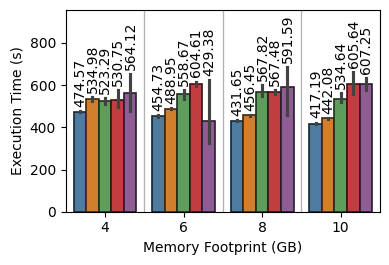

Comparison to 'MANTA' at same GB
DuckDB-TPCH-sf100
 GB     policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4       ARMS       534.98        474.57    60.41         12.73            1.13
  4 HybridTier       523.29        474.57    48.72         10.27            1.10
  4      Nomad       530.75        474.57    56.18         11.84            1.12
  4        TPP       564.12        474.57    89.55         18.87            1.19
  6       ARMS       488.95        454.73    34.22          7.52            1.08
  6 HybridTier       558.67        454.73   103.94         22.86            1.23
  6      Nomad       604.61        454.73   149.87         32.96            1.33
  6        TPP       429.38        454.73   -25.36         -5.58            0.94
  8       ARMS       456.45        431.65    24.80          5.75            1.06
  8 HybridTier       567.82        431.65   136.18         31.55            1.32
  8      Nomad       567.48        431.65   135.83        

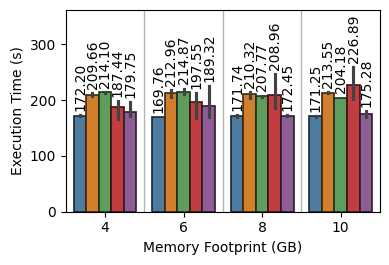

Comparison to 'MANTA' at same GB
XSBench
 GB     policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4       ARMS       209.66        172.20    37.46         21.76            1.22
  4 HybridTier       214.10        172.20    41.91         24.34            1.24
  4      Nomad       187.44        172.20    15.24          8.85            1.09
  4        TPP       179.75        172.20     7.56          4.39            1.04
  6       ARMS       212.96        169.76    43.20         25.45            1.25
  6 HybridTier       214.87        169.76    45.11         26.57            1.27
  6      Nomad       197.55        169.76    27.79         16.37            1.16
  6        TPP       189.32        169.76    19.56         11.52            1.12
  8       ARMS       210.32        171.74    38.58         22.47            1.22
  8 HybridTier       207.77        171.74    36.04         20.98            1.21
  8      Nomad       208.96        171.74    37.23         21.68    

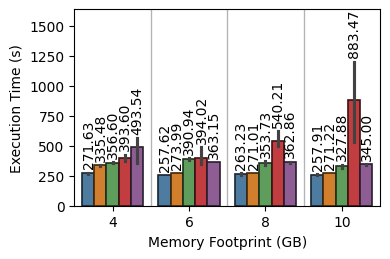

Comparison to 'MANTA' at same GB
bc-kron.sg
 GB     policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4       ARMS       335.48        271.63    63.84         23.50            1.24
  4 HybridTier       356.60        271.63    84.97         31.28            1.31
  4      Nomad       393.60        271.63   121.97         44.90            1.45
  4        TPP       493.54        271.63   221.90         81.69            1.82
  6       ARMS       273.99        257.62    16.36          6.35            1.06
  6 HybridTier       390.94        257.62   133.31         51.75            1.52
  6      Nomad       394.02        257.62   136.40         52.94            1.53
  6        TPP       363.15        257.62   105.52         40.96            1.41
  8       ARMS       271.01        263.23     7.78          2.96            1.03
  8 HybridTier       353.73        263.23    90.50         34.38            1.34
  8      Nomad       540.21        263.23   276.98        105.22 

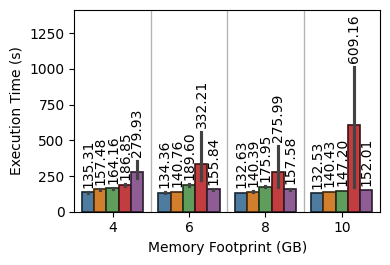

Comparison to 'MANTA' at same GB
bc-twitter.sg
 GB     policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4       ARMS       157.48        135.31    22.17         16.38            1.16
  4 HybridTier       164.16        135.31    28.84         21.32            1.21
  4      Nomad       186.85        135.31    51.54         38.09            1.38
  4        TPP       279.93        135.31   144.62        106.88            2.07
  6       ARMS       140.76        134.36     6.41          4.77            1.05
  6 HybridTier       189.60        134.36    55.24         41.11            1.41
  6      Nomad       332.21        134.36   197.85        147.25            2.47
  6        TPP       155.84        134.36    21.49         15.99            1.16
  8       ARMS       140.39        132.63     7.76          5.85            1.06
  8 HybridTier       175.95        132.63    43.32         32.66            1.33
  8      Nomad       275.99        132.63   143.36        108.

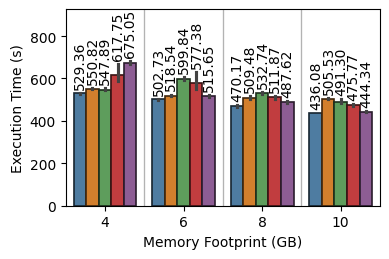

Comparison to 'MANTA' at same GB
faiss_10M
 GB     policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4       ARMS       550.82        529.36    21.46          4.05            1.04
  4 HybridTier       547.89        529.36    18.53          3.50            1.04
  4      Nomad       617.75        529.36    88.40         16.70            1.17
  4        TPP       675.05        529.36   145.70         27.52            1.28
  6       ARMS       518.54        502.73    15.81          3.15            1.03
  6 HybridTier       599.84        502.73    97.11         19.32            1.19
  6      Nomad       577.38        502.73    74.65         14.85            1.15
  6        TPP       515.65        502.73    12.92          2.57            1.03
  8       ARMS       509.48        470.17    39.31          8.36            1.08
  8 HybridTier       532.74        470.17    62.58         13.31            1.13
  8      Nomad       511.87        470.17    41.71          8.87  

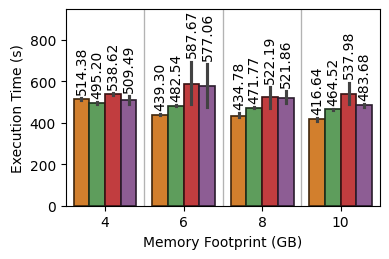

No 'MANTA' rows found for workload 'lulesh2.0_s400'.



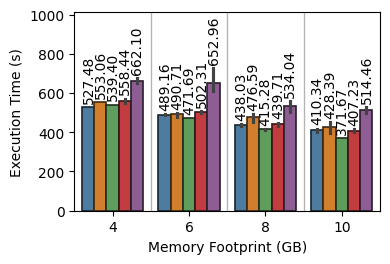

Comparison to 'MANTA' at same GB
mg.D.x
 GB     policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4       ARMS       553.06        527.48    25.58          4.85            1.05
  4 HybridTier       539.40        527.48    11.92          2.26            1.02
  4      Nomad       558.44        527.48    30.96          5.87            1.06
  4        TPP       662.10        527.48   134.62         25.52            1.26
  6       ARMS       490.71        489.16     1.55          0.32            1.00
  6 HybridTier       471.69        489.16   -17.46         -3.57            0.96
  6      Nomad       502.31        489.16    13.15          2.69            1.03
  6        TPP       652.96        489.16   163.80         33.49            1.33
  8       ARMS       476.59        438.03    38.56          8.80            1.09
  8 HybridTier       415.28        438.03   -22.75         -5.19            0.95
  8      Nomad       439.71        438.03     1.68          0.38     

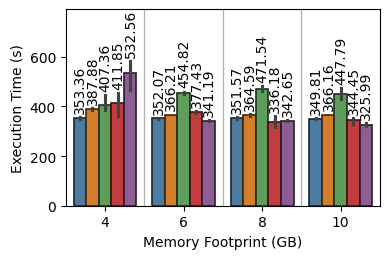

Comparison to 'MANTA' at same GB
pr-kron.sg
 GB     policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4       ARMS       387.88        353.36    34.53          9.77            1.10
  4 HybridTier       407.36        353.36    54.00         15.28            1.15
  4      Nomad       411.85        353.36    58.49         16.55            1.17
  4        TPP       532.56        353.36   179.21         50.72            1.51
  6       ARMS       366.21        352.07    14.14          4.02            1.04
  6 HybridTier       454.82        352.07   102.76         29.19            1.29
  6      Nomad       377.43        352.07    25.36          7.20            1.07
  6        TPP       341.19        352.07   -10.88         -3.09            0.97
  8       ARMS       364.59        351.57    13.02          3.70            1.04
  8 HybridTier       471.54        351.57   119.96         34.12            1.34
  8      Nomad       336.18        351.57   -15.39         -4.38 

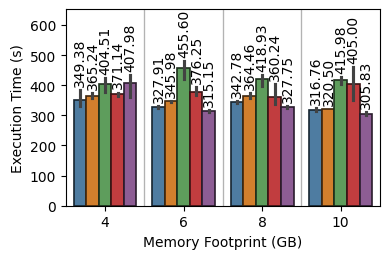

Comparison to 'MANTA' at same GB
pr-twitter.sg
 GB     policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4       ARMS       365.24        349.38    15.87          4.54            1.05
  4 HybridTier       404.51        349.38    55.14         15.78            1.16
  4      Nomad       371.14        349.38    21.76          6.23            1.06
  4        TPP       407.98        349.38    58.61         16.77            1.17
  6       ARMS       345.98        327.91    18.07          5.51            1.06
  6 HybridTier       455.60        327.91   127.69         38.94            1.39
  6      Nomad       376.25        327.91    48.34         14.74            1.15
  6        TPP       315.15        327.91   -12.76         -3.89            0.96
  8       ARMS       364.46        342.78    21.68          6.32            1.06
  8 HybridTier       418.93        342.78    76.15         22.21            1.22
  8      Nomad       360.24        342.78    17.46          5.

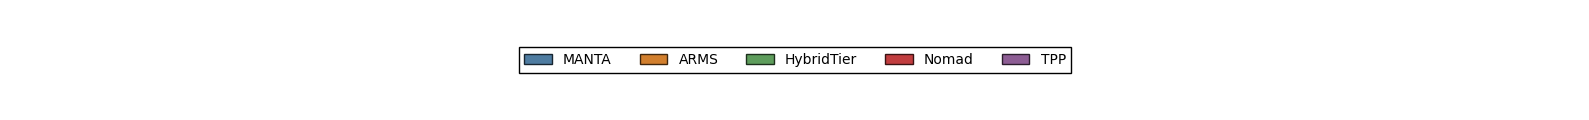

In [22]:
roots_6_2 = lambda workload: {
        "MANTA": ("6.2+", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/model_6.2/{workload}")),
        "ARMS": ("6.2+", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/arms_6.2/{workload}")),
        "HybridTier": ("6.2+", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/hybridtier/{workload}")),
        "Nomad": ("5.15-rc6+", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/nomad/{workload}")),
        "TPP": ("5.15+", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/tpp/{workload}")),
    }

df = generate_df(roots_6_2)
df_plot = df[df["MiB"].isin([4000, 6000, 8000, 10000])]
df_plot["policy_penalty"] = df_plot.apply(lambda row: f"{row['policy']} {row['penalty']}", axis=1)
plot_df(df_plot, "6_2")

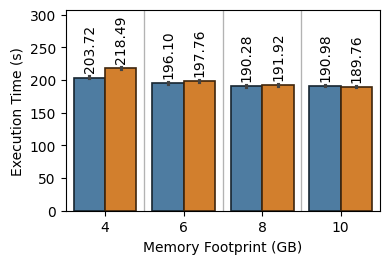

Comparison to 'MANTA' at same GB
DuckDB-TPCH-sf100
 GB policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4   ARMS       218.49        203.72    14.78          7.25            1.07
  6   ARMS       197.76        196.10     1.66          0.85            1.01
  8   ARMS       191.92        190.28     1.64          0.86            1.01
 10   ARMS       189.76        190.98    -1.22         -0.64            0.99



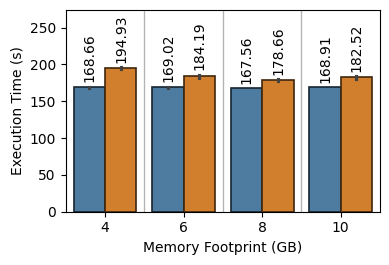

Comparison to 'MANTA' at same GB
XSBench
 GB policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4   ARMS       194.93        168.66    26.27         15.58            1.16
  6   ARMS       184.19        169.02    15.16          8.97            1.09
  8   ARMS       178.66        167.56    11.10          6.62            1.07
 10   ARMS       182.52        168.91    13.61          8.06            1.08



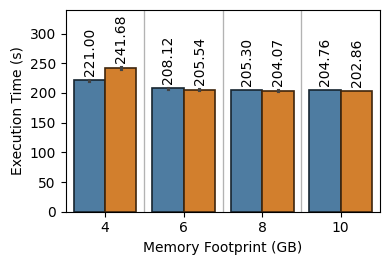

Comparison to 'MANTA' at same GB
bc-kron.sg
 GB policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4   ARMS       241.68        221.00    20.68          9.36            1.09
  6   ARMS       205.54        208.12    -2.58         -1.24            0.99
  8   ARMS       204.07        205.30    -1.23         -0.60            0.99
 10   ARMS       202.86        204.76    -1.90         -0.93            0.99



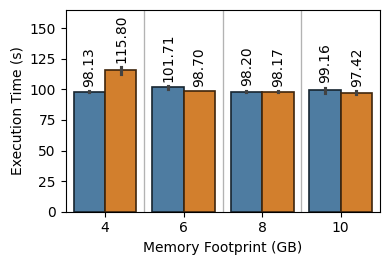

Comparison to 'MANTA' at same GB
bc-twitter.sg
 GB policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4   ARMS       115.80         98.13    17.68         18.02            1.18
  6   ARMS        98.70        101.71    -3.01         -2.96            0.97
  8   ARMS        98.17         98.20    -0.03         -0.03            1.00
 10   ARMS        97.42         99.16    -1.74         -1.75            0.98



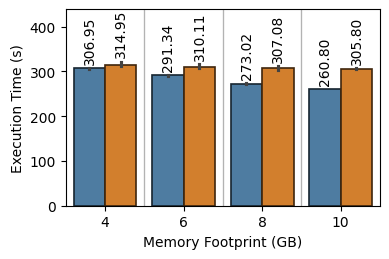

Comparison to 'MANTA' at same GB
faiss_10M
 GB policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4   ARMS       314.95        306.95     8.00          2.61            1.03
  6   ARMS       310.11        291.34    18.77          6.44            1.06
  8   ARMS       307.08        273.02    34.06         12.48            1.12
 10   ARMS       305.80        260.80    45.01         17.26            1.17



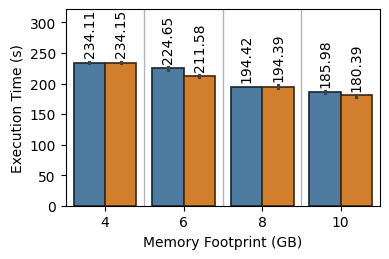

Comparison to 'MANTA' at same GB
mg.D.x
 GB policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4   ARMS       234.15        234.11     0.03          0.01            1.00
  6   ARMS       211.58        224.65   -13.07         -5.82            0.94
  8   ARMS       194.39        194.42    -0.03         -0.01            1.00
 10   ARMS       180.39        185.98    -5.59         -3.00            0.97



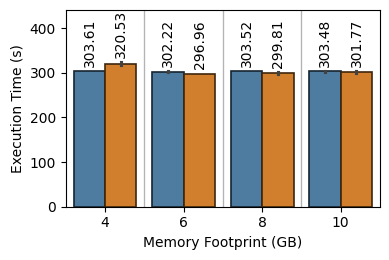

Comparison to 'MANTA' at same GB
pr-kron.sg
 GB policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4   ARMS       320.53        303.61    16.92          5.57            1.06
  6   ARMS       296.96        302.22    -5.26         -1.74            0.98
  8   ARMS       299.81        303.52    -3.71         -1.22            0.99
 10   ARMS       301.77        303.48    -1.72         -0.57            0.99



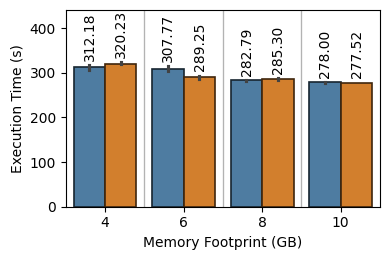

Comparison to 'MANTA' at same GB
pr-twitter.sg
 GB policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4   ARMS       320.23        312.18     8.04          2.58            1.03
  6   ARMS       289.25        307.77   -18.52         -6.02            0.94
  8   ARMS       285.30        282.79     2.50          0.89            1.01
 10   ARMS       277.52        278.00    -0.48         -0.17            1.00



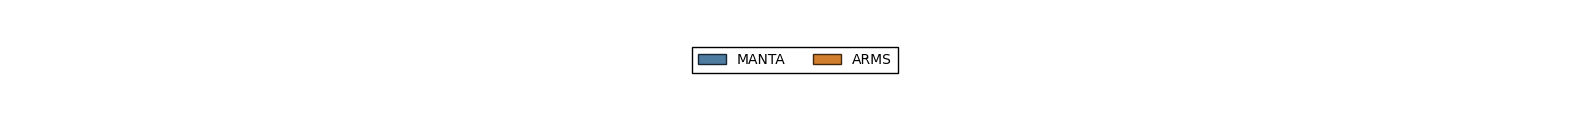

In [23]:
roots_6_18 = lambda workload: {
        #"arms 6.18": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/arms-6.18/{workload}")),
        "MANTA": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/model_6.18/{workload}")),
        "ARMS": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/arms_6.18/{workload}")),
    }

df = generate_df(roots_6_18)
df_plot = df[df["MiB"].isin([4000, 6000, 8000, 10000])]
df_plot["policy_penalty"] = df_plot.apply(lambda row: f"{row['policy']} {row['penalty']}", axis=1)
plot_df(df_plot, "6_18")

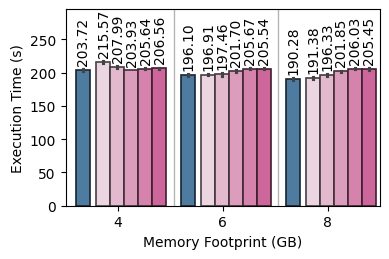

Comparison to 'MANTA' at same GB
DuckDB-TPCH-sf100
 GB    policy_penalty  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4         MANTA 0.1       203.72        203.72     0.00          0.00            1.00
  4 Cost Scaler 0.125       215.57        203.72    11.86          5.82            1.06
  4  Cost Scaler 0.25       207.99        203.72     4.27          2.10            1.02
  4   Cost Scaler 0.5       203.93        203.72     0.21          0.10            1.00
  4   Cost Scaler 1.0       205.64        203.72     1.93          0.95            1.01
  4   Cost Scaler 1.5       206.56        203.72     2.85          1.40            1.01
  6         MANTA 0.1       196.10        196.10     0.00          0.00            1.00
  6 Cost Scaler 0.125       196.91        196.10     0.81          0.41            1.00
  6  Cost Scaler 0.25       197.46        196.10     1.36          0.69            1.01
  6   Cost Scaler 0.5       201.70        196.10     5.60          2.

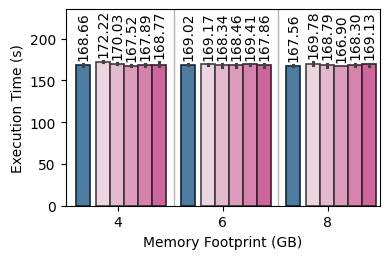

Comparison to 'MANTA' at same GB
XSBench
 GB    policy_penalty  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4         MANTA 0.1       168.66        168.66     0.00          0.00            1.00
  4 Cost Scaler 0.125       172.22        168.66     3.56          2.11            1.02
  4  Cost Scaler 0.25       170.03        168.66     1.38          0.82            1.01
  4   Cost Scaler 0.5       167.52        168.66    -1.13         -0.67            0.99
  4   Cost Scaler 1.0       167.89        168.66    -0.77         -0.46            1.00
  4   Cost Scaler 1.5       168.77        168.66     0.12          0.07            1.00
  6         MANTA 0.1       169.02        169.02     0.00          0.00            1.00
  6 Cost Scaler 0.125       169.17        169.02     0.14          0.08            1.00
  6  Cost Scaler 0.25       168.34        169.02    -0.68         -0.40            1.00
  6   Cost Scaler 0.5       168.46        169.02    -0.56         -0.33        

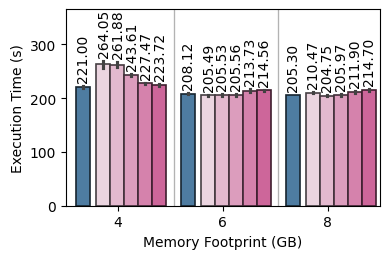

Comparison to 'MANTA' at same GB
bc-kron.sg
 GB    policy_penalty  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4         MANTA 0.1       221.00        221.00     0.00          0.00            1.00
  4 Cost Scaler 0.125       264.05        221.00    43.05         19.48            1.19
  4  Cost Scaler 0.25       261.88        221.00    40.88         18.50            1.18
  4   Cost Scaler 0.5       243.61        221.00    22.61         10.23            1.10
  4   Cost Scaler 1.0       227.47        221.00     6.47          2.93            1.03
  4   Cost Scaler 1.5       223.72        221.00     2.72          1.23            1.01
  6         MANTA 0.1       208.12        208.12     0.00          0.00            1.00
  6 Cost Scaler 0.125       205.49        208.12    -2.63         -1.26            0.99
  6  Cost Scaler 0.25       205.53        208.12    -2.58         -1.24            0.99
  6   Cost Scaler 0.5       205.56        208.12    -2.56         -1.23     

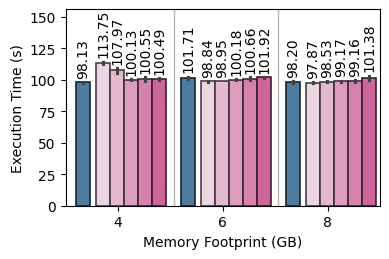

Comparison to 'MANTA' at same GB
bc-twitter.sg
 GB    policy_penalty  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4         MANTA 0.1        98.13         98.13     0.00          0.00            1.00
  4 Cost Scaler 0.125       113.75         98.13    15.63         15.92            1.16
  4  Cost Scaler 0.25       107.97         98.13     9.84         10.03            1.10
  4   Cost Scaler 0.5       100.13         98.13     2.00          2.04            1.02
  4   Cost Scaler 1.0       100.55         98.13     2.43          2.47            1.02
  4   Cost Scaler 1.5       100.49         98.13     2.37          2.41            1.02
  6         MANTA 0.1       101.71        101.71     0.00          0.00            1.00
  6 Cost Scaler 0.125        98.84        101.71    -2.88         -2.83            0.97
  6  Cost Scaler 0.25        98.95        101.71    -2.76         -2.71            0.97
  6   Cost Scaler 0.5       100.18        101.71    -1.53         -1.51  

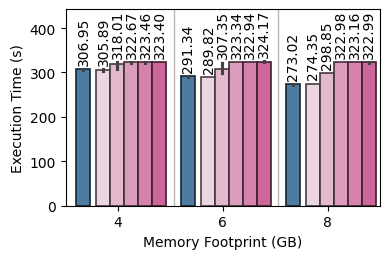

Comparison to 'MANTA' at same GB
faiss_10M
 GB    policy_penalty  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4         MANTA 0.1       306.95        306.95     0.00          0.00            1.00
  4 Cost Scaler 0.125       305.89        306.95    -1.06         -0.35            1.00
  4  Cost Scaler 0.25       318.01        306.95    11.06          3.60            1.04
  4   Cost Scaler 0.5       322.67        306.95    15.72          5.12            1.05
  4   Cost Scaler 1.0       323.46        306.95    16.51          5.38            1.05
  4   Cost Scaler 1.5       323.40        306.95    16.45          5.36            1.05
  6         MANTA 0.1       291.34        291.34     0.00          0.00            1.00
  6 Cost Scaler 0.125       289.82        291.34    -1.52         -0.52            0.99
  6  Cost Scaler 0.25       307.35        291.34    16.02          5.50            1.05
  6   Cost Scaler 0.5       323.34        291.34    32.00         10.98      

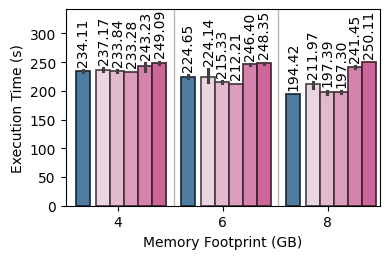

Comparison to 'MANTA' at same GB
mg.D.x
 GB    policy_penalty  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4         MANTA 0.1       234.11        234.11     0.00          0.00            1.00
  4 Cost Scaler 0.125       237.17        234.11     3.05          1.30            1.01
  4  Cost Scaler 0.25       233.84        234.11    -0.27         -0.12            1.00
  4   Cost Scaler 0.5       233.28        234.11    -0.83         -0.36            1.00
  4   Cost Scaler 1.0       243.23        234.11     9.12          3.89            1.04
  4   Cost Scaler 1.5       249.09        234.11    14.98          6.40            1.06
  6         MANTA 0.1       224.65        224.65     0.00          0.00            1.00
  6 Cost Scaler 0.125       224.14        224.65    -0.51         -0.23            1.00
  6  Cost Scaler 0.25       215.33        224.65    -9.32         -4.15            0.96
  6   Cost Scaler 0.5       212.21        224.65   -12.44         -5.54         

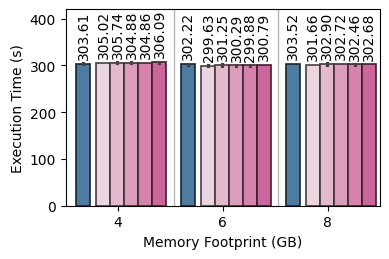

Comparison to 'MANTA' at same GB
pr-kron.sg
 GB    policy_penalty  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4         MANTA 0.1       303.61        303.61     0.00          0.00            1.00
  4 Cost Scaler 0.125       305.02        303.61     1.41          0.46            1.00
  4  Cost Scaler 0.25       305.74        303.61     2.13          0.70            1.01
  4   Cost Scaler 0.5       304.88        303.61     1.27          0.42            1.00
  4   Cost Scaler 1.0       304.86        303.61     1.25          0.41            1.00
  4   Cost Scaler 1.5       306.09        303.61     2.47          0.81            1.01
  6         MANTA 0.1       302.22        302.22     0.00          0.00            1.00
  6 Cost Scaler 0.125       299.63        302.22    -2.59         -0.86            0.99
  6  Cost Scaler 0.25       301.25        302.22    -0.97         -0.32            1.00
  6   Cost Scaler 0.5       300.29        302.22    -1.93         -0.64     

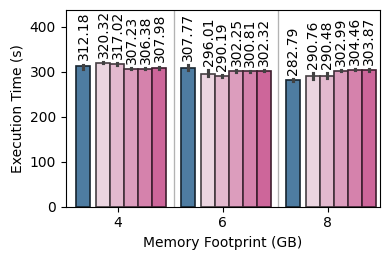

Comparison to 'MANTA' at same GB
pr-twitter.sg
 GB    policy_penalty  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4         MANTA 0.1       312.18        312.18     0.00          0.00            1.00
  4 Cost Scaler 0.125       320.32        312.18     8.13          2.61            1.03
  4  Cost Scaler 0.25       317.02        312.18     4.84          1.55            1.02
  4   Cost Scaler 0.5       307.23        312.18    -4.95         -1.59            0.98
  4   Cost Scaler 1.0       306.38        312.18    -5.80         -1.86            0.98
  4   Cost Scaler 1.5       307.98        312.18    -4.20         -1.35            0.99
  6         MANTA 0.1       307.77        307.77     0.00          0.00            1.00
  6 Cost Scaler 0.125       296.01        307.77   -11.77         -3.82            0.96
  6  Cost Scaler 0.25       290.19        307.77   -17.58         -5.71            0.94
  6   Cost Scaler 0.5       302.25        307.77    -5.52         -1.79  

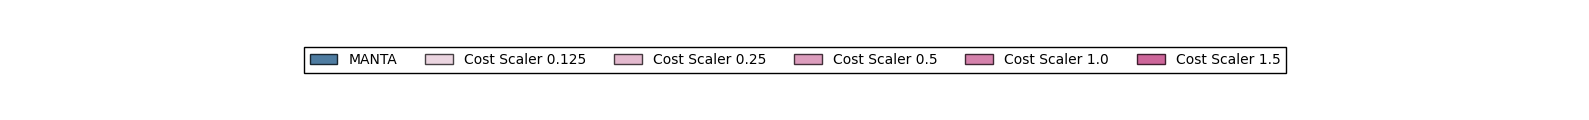

In [24]:
roots_6_18_cost_ablation = lambda workload: {
        "MANTA": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/model_6.18/{workload}")),
        "Cost Scaler": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/model_6.18_cost_ablation/{workload}")),
    }

df = generate_df(roots_6_18_cost_ablation)
df_plot = df[(df["MiB"].isin([4000, 6000, 8000])) & df["penalty"].isin([0.1, 0.125, 0.25, 0.5, 1.0, 1.5])]
df_plot["policy_penalty"] = df_plot.apply(lambda row: f"{row['policy']} {row['penalty']}", axis=1)
plot_df(df_plot, "6_18_cost_ablation", show_penalty_scaler=True)

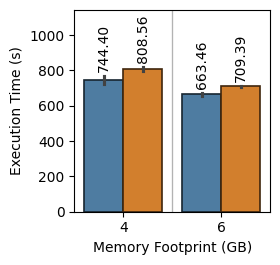

Comparison to 'MANTA' at same GB
bc-twitter.sg
 GB policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4   ARMS       808.56        744.40    64.16          8.62            1.09
  6   ARMS       709.39        663.46    45.93          6.92            1.07



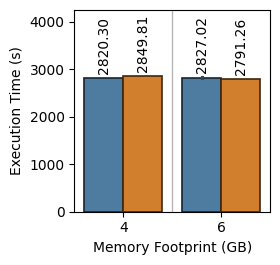

Comparison to 'MANTA' at same GB
pr-twitter.sg
 GB policy  real_mean_s  model_mean_s  delta_s  pct_vs_model  ratio_vs_model
  4   ARMS      2849.81       2820.30    29.50          1.05            1.01
  6   ARMS      2791.26       2827.02   -35.75         -1.26            0.99



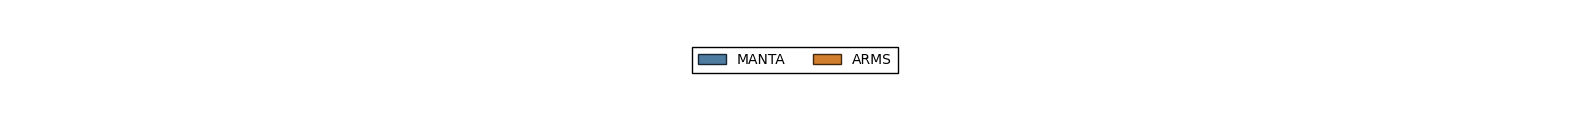

: 

In [ ]:
roots_6_18_long = lambda workload: {
        #"arms 6.18": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/arms-6.18/{workload}")),
        "MANTA": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/model_6.18_long/{workload}")),
        "ARMS": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/c220g5_final/arms_6.18_long/{workload}")),
    }

df = generate_df(roots_6_18_long)
df_plot = df[df["MiB"].isin([4000, 6000])]
df_plot["policy_penalty"] = df_plot.apply(lambda row: f"{row['policy']} {row['penalty']}", axis=1)
plot_df(df_plot, "6_18_long", width_override=2.9)

In [26]:
models = pd.DataFrame([
    {
        "name": "bc-kron.sg",
        "R2": 0.94,
        "MAE": 14.4,
        "RMSE": 68.83
    },
    {
        "name": "pr-kron.sg",
        "R2": 0.94,
        "MAE": 12.3,
        "RMSE": 125.98
    },
    {
        "name": "bc-twitter.sg",
        "R2": 0.86,
        "MAE": 20.6,
        "RMSE": 132.25
    },
    {
        "name": "pr-twitter.sg",
        "R2": 0.996,
        "MAE": 6.12,
        "RMSE": 58.08
    },
    {
        "name": "faiss_10M",
        "R2": 0.52,
        "MAE": 20.32,
        "RMSE": 445.114
    },
    {
        "name": "mg.D.x",
        "R2": 0.89,
        "MAE": 14.76,
        "RMSE": 382.47
    },
    {
        "name": "DuckDB-TPCH-sf100",
        "R2": 0.85,
        "MAE": 374.43,
        "RMSE": 2725.63
    },{
        "name": "XSBench",
        "R2": 0.91,
        "MAE": 12.66,
        "RMSE": 422.32
    }
])

runs = pd.DataFrame([
    {
        "name": "bc-kron.sg",
        "size": 2,
        "accesses": 150,
        "best scaler": 3.5,
        "weight": 1 
    },
    {
        "name": "bc-kron.sg",
        "size": 4,
        "accesses": 8,
        "best scaler": .35, 
        "weight": 4
    },
    {
        "name": "bc-kron.sg",
        "size": 6,
        "accesses": 8,
        "best scaler": .35, 
        "weight": 4
    },
    {
        "name": "bc-kron.sg",
        "size": 8,
        "accesses": 8,
        "best scaler": .35, 
        "weight": 4
    },
    {
        "name": "bc-twitter.sg",
        "size": 2,
        "accesses": 15,
        "best scaler": .7, 
        "weight": 1
    },
    {
        "name": "bc-twitter.sg",
        "size": 4,
        "accesses": 8,
        "best scaler": .2, 
        "weight": 2
    },
    {
        "name": "bc-twitter.sg",
        "size": 6,
        "accesses": 5,
        "best scaler": .2, 
        "weight": 2
    },
    {
        "name": "bc-twitter.sg",
        "size": 8,
        "accesses": 3,
        "best scaler": .2, 
        "weight": 2
    },
    {
        "name": "pr-kron.sg",
        "size": 2,
        "accesses": 2.25,
        "best scaler": .5,
        "weight": 0.2
    },
    {
        "name": "pr-kron.sg",
        "size": 4,
        "accesses": 2.25,
        "best scaler": .5,
        "weight": 0.2
    },
    {
        "name": "pr-kron.sg",
        "size": 6,
        "accesses": 2.25,
        "best scaler": .5,
        "weight": 0.2
    },
    {
        "name": "pr-kron.sg",
        "size": 8,
        "accesses": 3,
        "best scaler": .5,
        "weight": 0.2
    },
    {
        "name": "pr-twitter.sg",
        "size": 2,
        "accesses": 13,
        "best scaler": 1.0, 
        "weight": 1
    },
    {
        "name": "pr-twitter.sg",
        "size": 4,
        "accesses": 10,
        "best scaler": 0.2,
        "weight": 2
    },
    {
        "name": "pr-twitter.sg",
        "size": 6,
        "accesses": 8,
        "best scaler": 0.2,
        "weight": 2
    },
    {
        "name": "pr-twitter.sg",
        "size": 8,
        "accesses": 0,
        "best scaler": 0.0625, 
        "weight": 2
    },
    {
        "name": "mg.D.x",
        "size": 2,
        "accesses": 40,
        "best scaler": 0.4,
        "weight": 1
    },
    {
        "name": "mg.D.x",
        "size": 4,
        "accesses": 40,
        "best scaler": 0.4,
        "weight": 1
    },
    {
        "name": "mg.D.x",
        "size": 6,
        "accesses": 40,
        "best scaler": 0.4,
        "weight": 1
    },
    {
        "name": "mg.D.x",
        "size": 8,
        "accesses": 40,
        "best scaler": 0.4,
        "weight": 1 
    },
    {
        "name": "DuckDB-TPCH-sf100",
        "size": 2,
        "accesses": 350,
        "best scaler": 6.0,
        "weight": 1 
    },
    {
        "name": "DuckDB-TPCH-sf100",
        "size": 4,
        "accesses": 150,
        "best scaler": 0.5,
        "weight": 2 
    },
    {
        "name": "DuckDB-TPCH-sf100",
        "size": 6,
        "accesses": 150,
        "best scaler": 0.5,
        "weight": 2 
    },
    {
        "name": "DuckDB-TPCH-sf100",
        "size": 8,
        "accesses": 100,
        "best scaler": 0.5,
        "weight": 2  
    },
    {
        "name": "XSBench",
        "size": 2,
        "accesses": 0.8,
        "best scaler": 0.625,
        "weight": 0.25
    },
    {
        "name": "XSBench",
        "size": 4,
        "accesses": 0.7,
        "best scaler": 0.625,
        "weight": 0.25
    },
    {
        "name": "XSBench",
        "size": 6,
        "accesses": 0.7,
        "best scaler": 0.625,
        "weight": 0.25
    },
    {
        "name": "XSBench",
        "size": 8,
        "accesses": 0.7,
        "best scaler": 0.5,
        "weight": 0.25
    },
    {
        "name": "faiss_10M",
        "size": 2,
        "accesses": 2.7,
        "best scaler": 0.125,
        "weight": 2
    },
    {
        "name": "faiss_10M",
        "size": 4,
        "accesses": 2.7,
        "best scaler": 0.125 / 3,
        "weight": 2
    },
    {
        "name": "faiss_10M",
        "size": 6,
        "accesses": 2.7,
        "best scaler": 0.125 / 3,
        "weight": 2
    },
    {
        "name": "faiss_10M",
        "size": 8,
        "accesses": 2.7,
        "best scaler": 0.125 / 3,
        "weight": 2 
    },
])

In [27]:
from sklearn.linear_model import LinearRegression

# Merge the dataframes
merged_df = runs.merge(models, on="name", how="left")

# Create and train the linear model
features = ["accesses"]
X = merged_df[features]
y = merged_df["best scaler"]
sample_weight = merged_df["weight"]

model = LinearRegression()
model.fit(X, y, sample_weight=sample_weight)

for feature in features:
    print(f"Coefficient for {feature}: {model.coef_[features.index(feature)]:.4f}")
print(f"Model intercept: {model.intercept_:.4f}")
print(f"R² score: {model.score(X, y, sample_weight=sample_weight):.4f}")

Coefficient for accesses: 0.0114
Model intercept: 0.0936
R² score: 0.6246


In [28]:
merged_df["hand calculated"] = 0.01 * merged_df["accesses"] + .1

In [29]:
merged_df["predicted_best_scaler"] = model.predict(X)
merged_df

,name,size,accesses,best scaler,weight,R2,MAE,RMSE,hand calculated,predicted_best_scaler
0,bc-kron.sg,2,150.00,3.500000,1.00,0.940,14.40,68.830,1.6000,1.806820
1,bc-kron.sg,4,8.00,0.350000,4.00,0.940,14.40,68.830,0.1800,0.184950
2,bc-kron.sg,6,8.00,0.350000,4.00,0.940,14.40,68.830,0.1800,0.184950
3,bc-kron.sg,8,8.00,0.350000,4.00,0.940,14.40,68.830,0.1800,0.184950
4,bc-twitter.sg,2,15.00,0.700000,1.00,0.860,20.60,132.250,0.2500,0.264901
5,bc-twitter.sg,4,8.00,0.200000,2.00,0.860,20.60,132.250,0.1800,0.184950
6,bc-twitter.sg,6,5.00,0.200000,2.00,0.860,20.60,132.250,0.1500,0.150685
7,bc-twitter.sg,8,3.00,0.200000,2.00,0.860,20.60,132.250,0.1300,0.127842
8,pr-kron.sg,2,2.25,0.500000,0.20,0.940,12.30,125.980,0.1225,0.119276
9,pr-kron.sg,4,2.25,0.500000,0.20,0.940,12.30,125.980,0.1225,0.119276


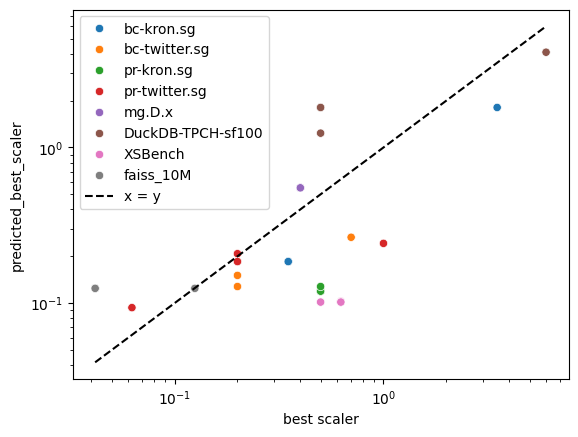

In [30]:

sns.scatterplot(merged_df, x="best scaler", y="predicted_best_scaler", hue="name")
plt.xscale("log")
plt.yscale("log")
ax = plt.gca()
min_val = min(merged_df["best scaler"].min(), merged_df["predicted_best_scaler"].min())
max_val = max(merged_df["best scaler"].max(), merged_df["predicted_best_scaler"].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black", label="x = y")
ax.legend()
plt.show()